# Mask2Former inference demo

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Mask2FormerForUniversalSegmentation
import PIL.Image, requests, io, matplotlib.pyplot as plt
from torchvision.transforms import v2
from matplotlib.colors import ListedColormap
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")
import glob

# define colors
colors = ["#000000","#f59331", "#33ddff", "#f078f0", "#ff007c", "#3df53d"]
colors_rgba = [c + '00' if i == 0 else c + 'FF' for i, c in enumerate(colors)]
cmap = ListedColormap(colors_rgba)

class Mask2FormerWrapper(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.model = Mask2FormerForUniversalSegmentation.from_pretrained(
            model_name,
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )
        self.num_classes = num_classes

    def forward(self, image_tensor, input_size=None):
        """image_tensor: normalized tensor (C,H,W); input_size=(H,W) or None to skip resize"""
        h_old, w_old = image_tensor.shape[1], image_tensor.shape[2]
        
        if input_size is not None:
            h_in, w_in = input_size
            image_resized = v2.Resize(size=(h_in, w_in), antialias=True)(image_tensor)
        else:
            # this mask2former backbone downsampled by the factor of 4, so just muliply 4 in adcance if not specified 
            h,w = h_old*4, w_old*4
            # however, too big might be problematic so capped at 2560
            # *2560 is heuristic! make sure to try multiple the input_size if you want to get best resutls
            h,w = min(2048,h),min(2048,w)
            image_resized = v2.Resize(size=(h,w), antialias=True)(image_tensor)

        outputs = self.model(pixel_values=image_resized.unsqueeze(0).cuda())
        cls_logits = outputs.class_queries_logits
        mask_logits = outputs.masks_queries_logits

        cls_probs = F.softmax(cls_logits, dim=-1)
        mask_probs = torch.sigmoid(mask_logits)

        b, q, h_small, w_small = mask_probs.shape
        mask_probs_flat = mask_probs.view(b, q, h_small * w_small)

        semantic_map = torch.bmm(cls_probs[:, :, :self.num_classes].transpose(1, 2), mask_probs_flat)
        semantic_map = semantic_map.view(b, self.num_classes, h_small, w_small)

        semantic_map = F.interpolate(
            semantic_map,
            size=(h_old, w_old),
            mode='bilinear',
            align_corners=False
        )
        return semantic_map  # (B, C, H_orig, W_orig)

In [2]:
checkpoint_path = "./m2f_tiny_1024_color_20260414_091312/model_epoch=050.ckpt"
model_name = "facebook/mask2former-swin-tiny-ade-semantic"

seg_model = Mask2FormerWrapper(model_name, num_classes=6)
checkpoint = torch.load(checkpoint_path, weights_only=False)
print(seg_model.load_state_dict(checkpoint['model_state_dict']))
seg_model = seg_model.bfloat16().cuda().eval()

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

You passed `num_labels=6` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-ade-semantic
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([7])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151, 256]) vs model:torch.Size([7, 256])
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([7])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


<All keys matched successfully>


# Wikipedia Samples

- https://en.wikipedia.org/wiki/File:Segmented_neutrophil.jpg
- https://en.wikipedia.org/wiki/File:Eosinophil_(cell).jpg
- https://en.wikipedia.org/wiki/File:Basophil_(cell).jpg
- https://en.wikipedia.org/wiki/File:Lymph.jpg
- https://en.wikipedia.org/wiki/File:Monocyte_(cell).jpg
- https://en.wikipedia.org/wiki/White_blood_cell_differential#/media/File:Neutrophil_-_Band_cell-1_(+lymphocytes).JPG
- https://it.wikipedia.org/wiki/File:Polycythemia_vera,_blood_smear.jpg
- https://en.wikipedia.org/wiki/File:Mononucléose_infectieuse-7.JPG 
- https://en.wikipedia.org/wiki/File:Flower_cell_in_mantle_cell_lymphoma_cropped.jpg
- https://en.wikipedia.org/wiki/File:Hem1Myelocyte.jpg
- https://en.wikipedia.org/wiki/File:PBBasophil.jpg


./wikipedia-wbc-samples/Segmented_neutrophil.jpg
w_ori, h_ori =  892 892
input_size (1024, 1024)


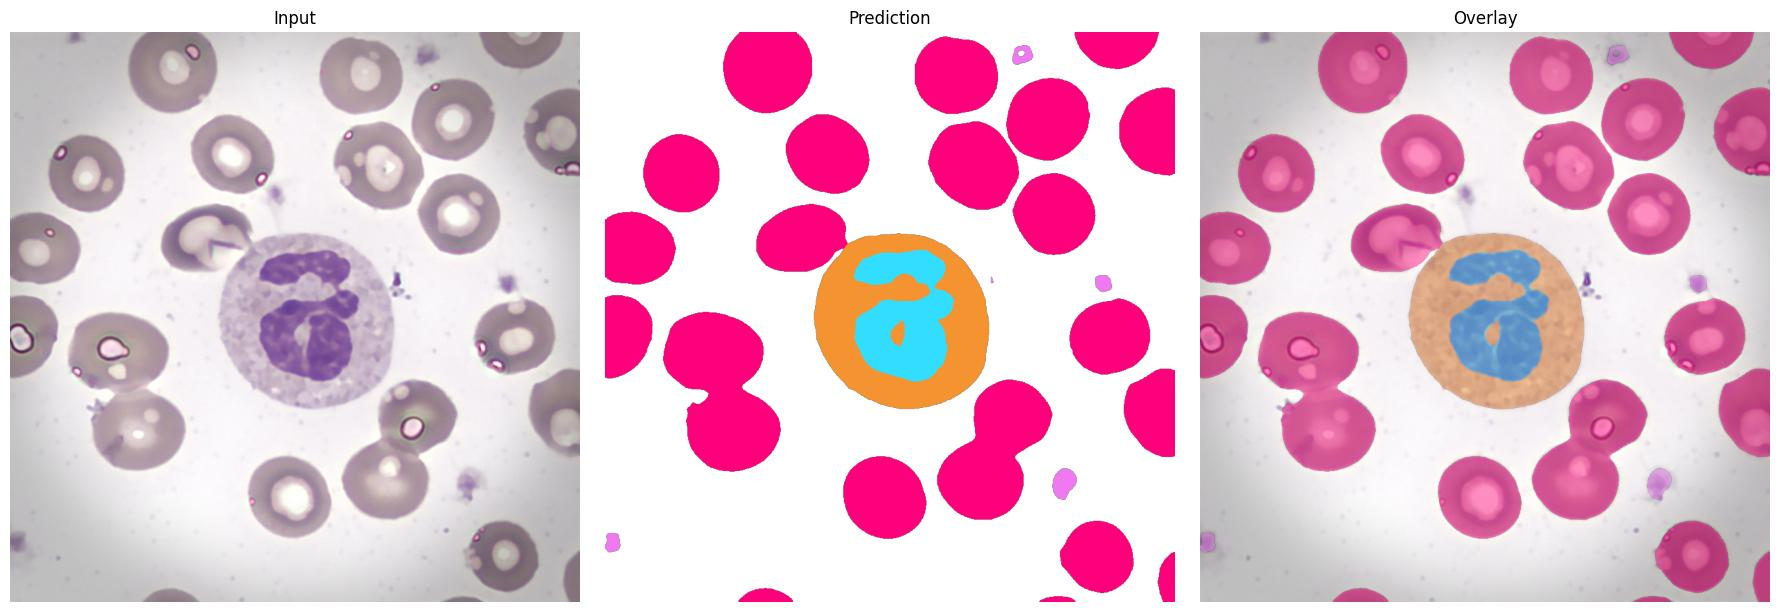

./wikipedia-wbc-samples/Polycythemia_vera,_blood_smear.jpg
w_ori, h_ori =  1920 1339
input_size None


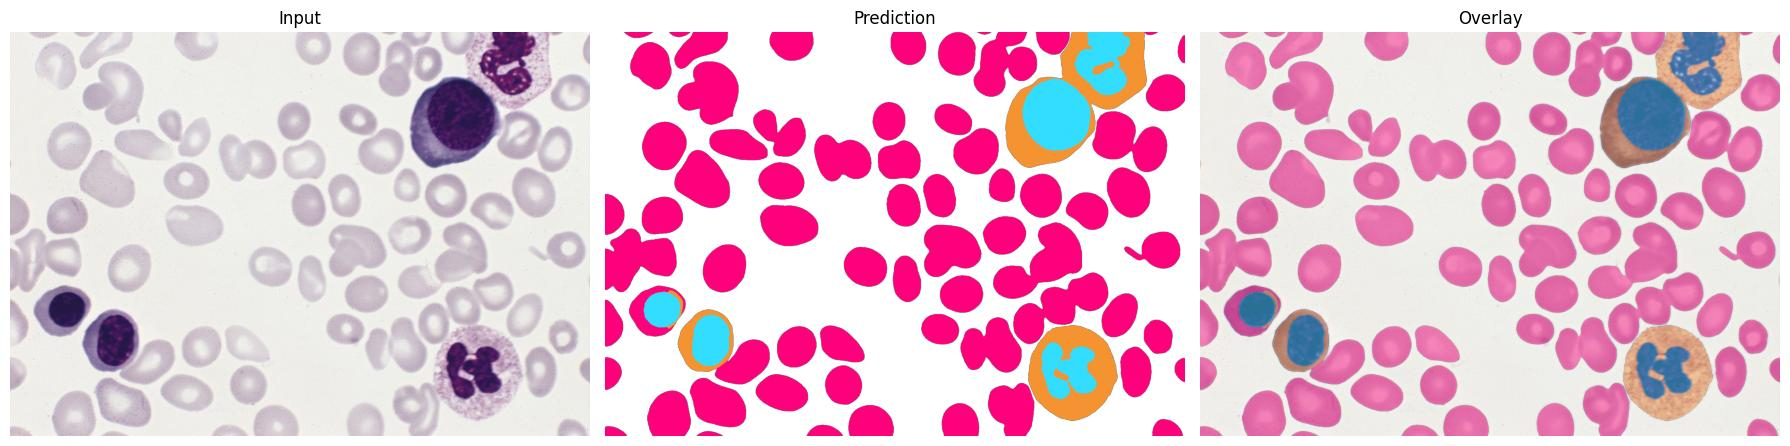

./wikipedia-wbc-samples/PBBasophil.jpg
w_ori, h_ori =  150 150
input_size (1024, 1024)


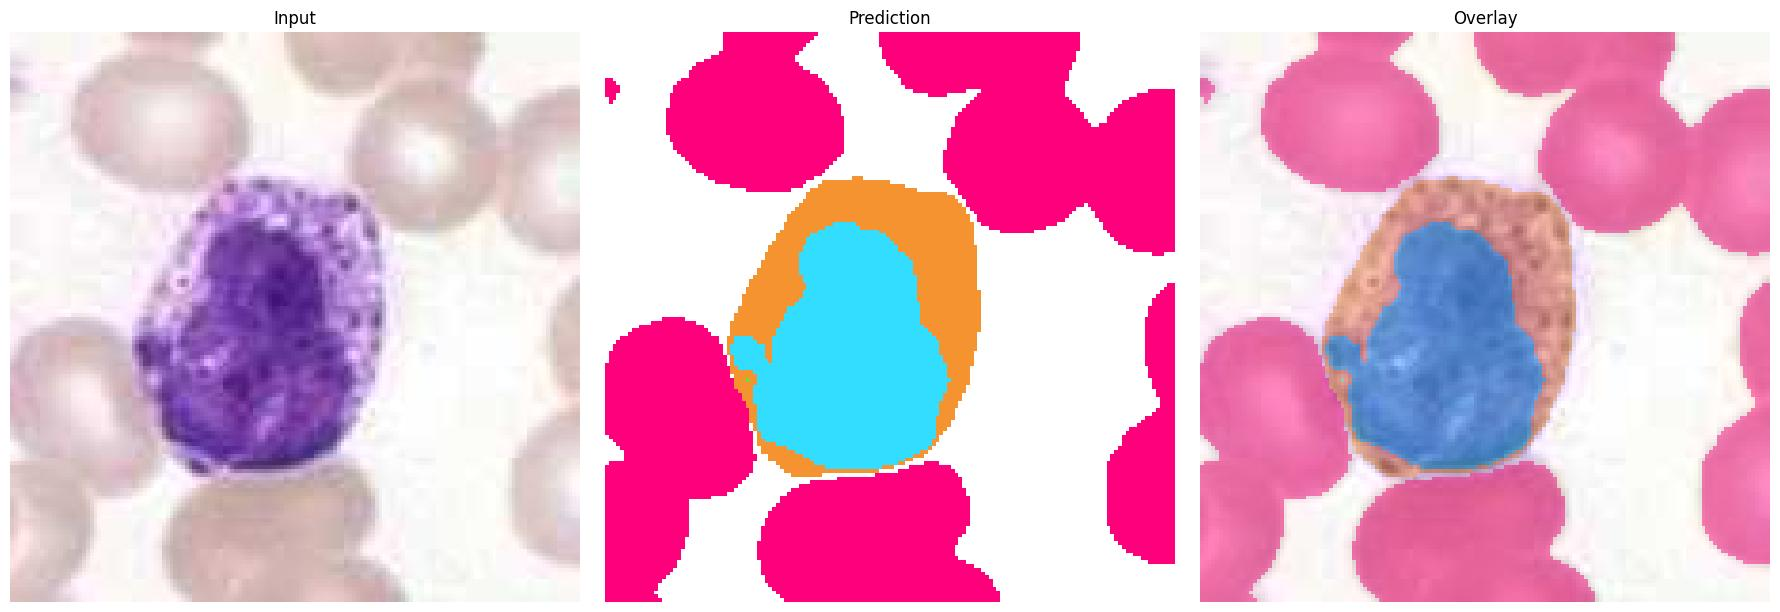

./wikipedia-wbc-samples/Monocyte_(cell).jpg
w_ori, h_ori =  893 893
input_size (1024, 1024)


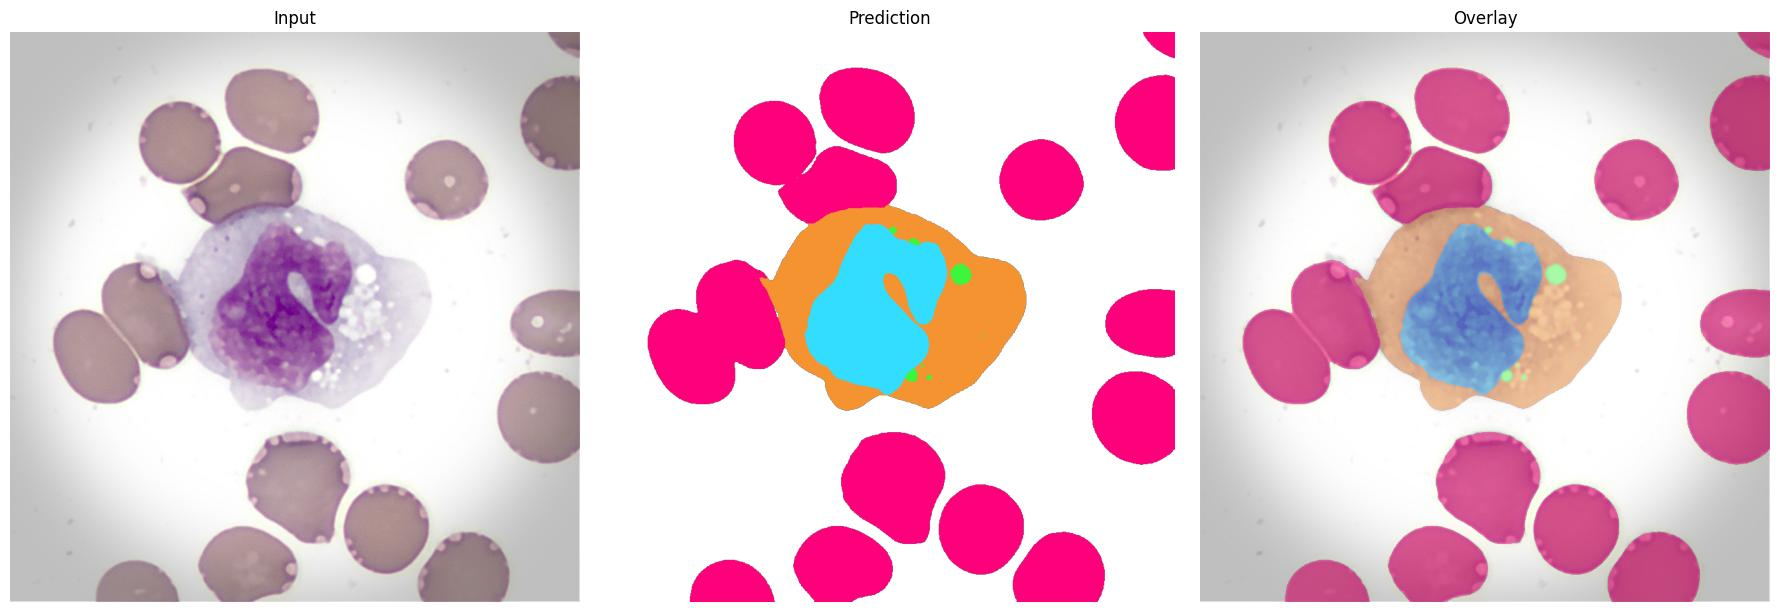

./wikipedia-wbc-samples/Lymph.jpg
w_ori, h_ori =  892 892
input_size (1024, 1024)


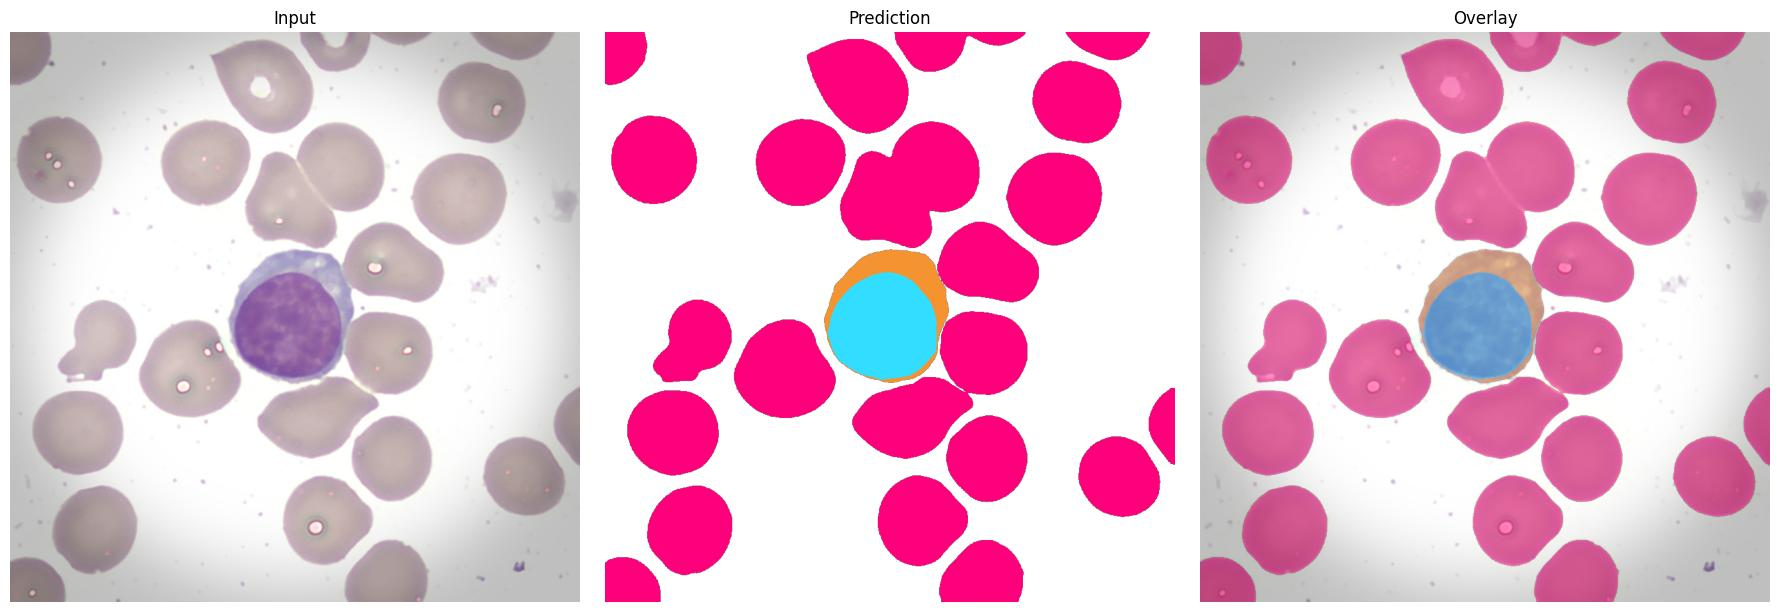

./wikipedia-wbc-samples/Hem1Myelocyte.jpg
w_ori, h_ori =  360 363
input_size (1024, 1033)


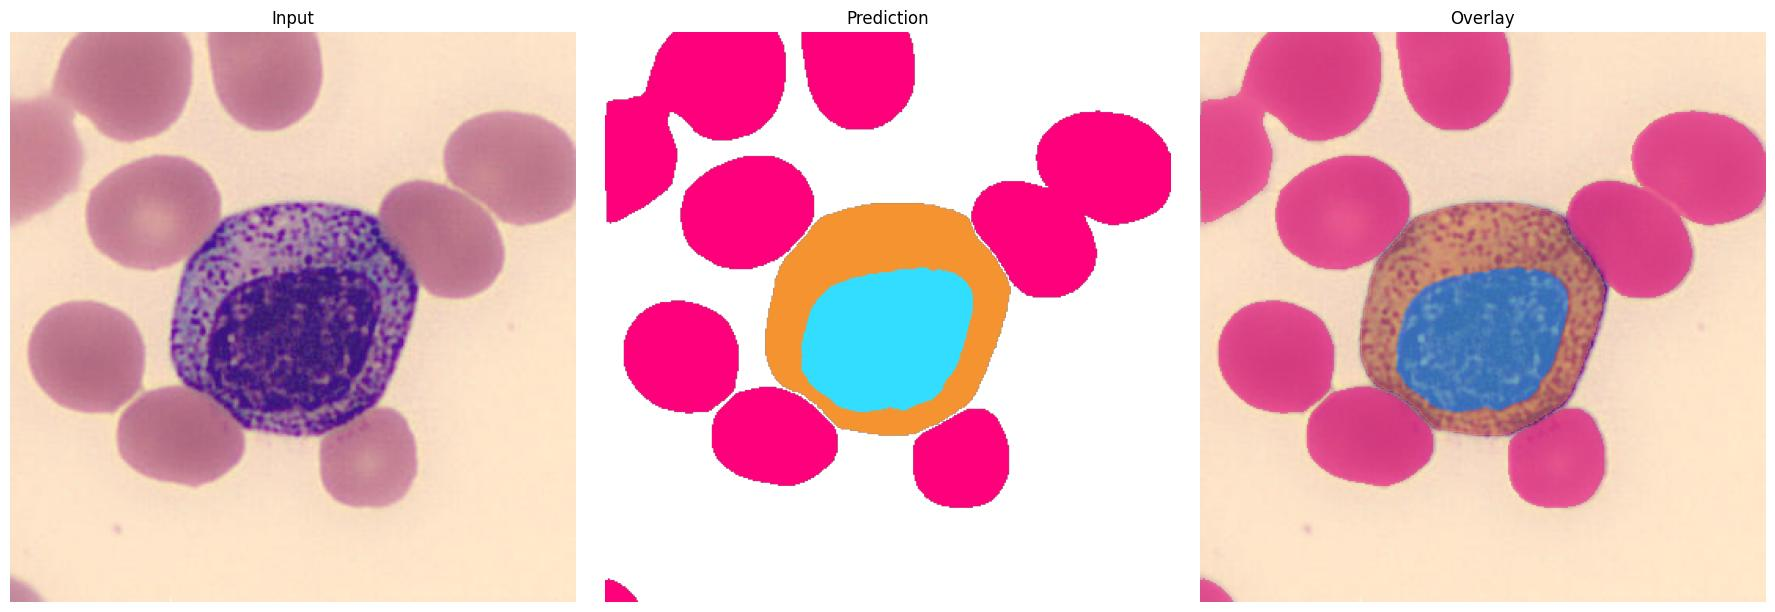

./wikipedia-wbc-samples/Flower_cell_in_mantle_cell_lymphoma_cropped.jpg
w_ori, h_ori =  595 595
input_size (1024, 1024)


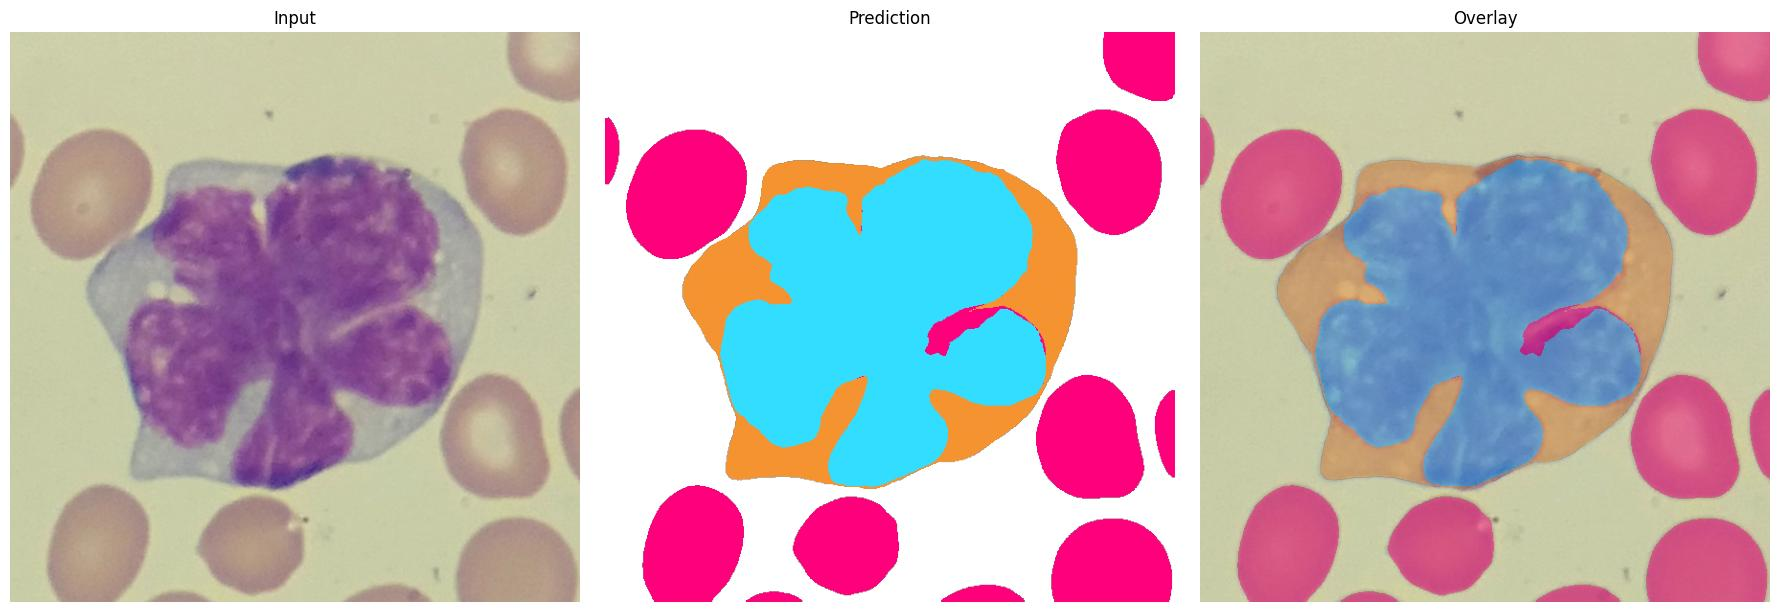

./wikipedia-wbc-samples/Eosinophil_(cell).jpg
w_ori, h_ori =  892 892
input_size (1024, 1024)


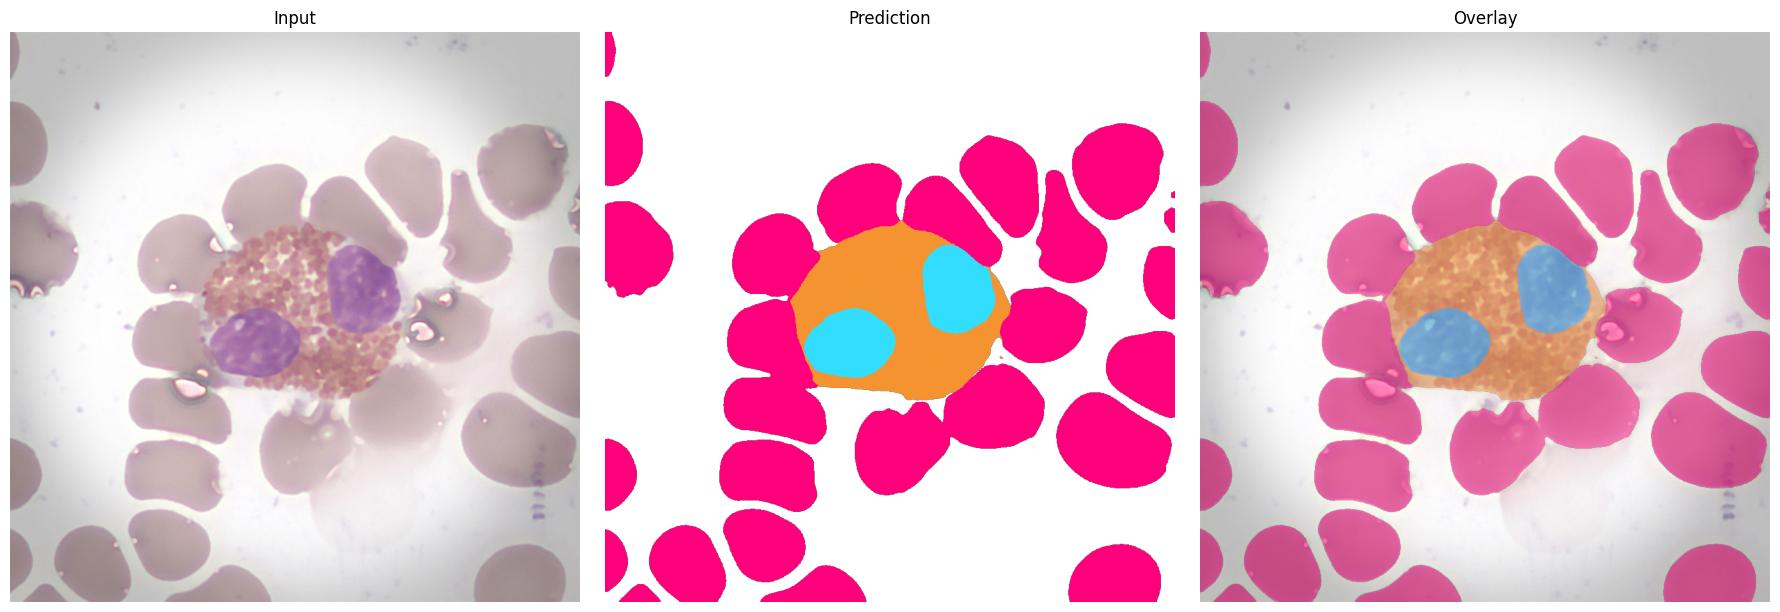

./wikipedia-wbc-samples/Basophil_(cell).jpg
w_ori, h_ori =  892 892
input_size (1024, 1024)


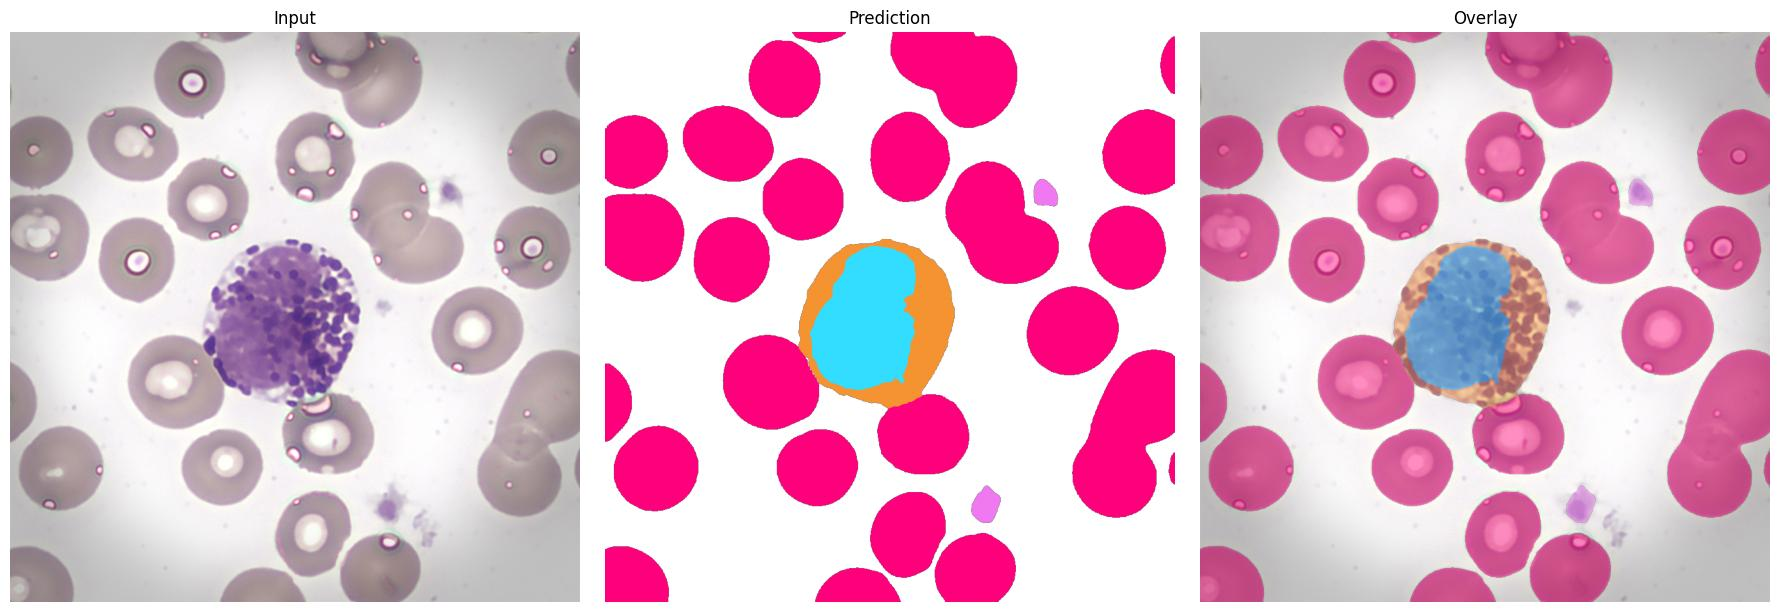

In [3]:
for filename in sorted(glob.glob("./wikipedia-wbc-samples/*.jpg"),reverse=True):
    print(filename)
    image = PIL.Image.open(filename).convert("RGB")
    image_tensor = transform(image)
    input_size = None
    if min(image.size) < 1024:
        scale = 1024/min(image.size) 
        input_size = (round(image.size[0]*scale),round(image.size[1]*scale))
    
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        pred_logits = seg_model(image_tensor.cuda(), input_size=input_size ) 
    pred = pred_logits[0].argmax(dim=0).cpu().numpy()

    w_ori, h_ori = image.size
    print("w_ori, h_ori = ", w_ori, h_ori)
    print("input_size", input_size)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image); axes[0].set_title('Input'); axes[0].axis('off')
    axes[1].imshow(pred, cmap=cmap, vmin=0, vmax=5); axes[1].set_title('Prediction'); axes[1].axis('off')
    axes[2].imshow(image); axes[2].imshow(pred, cmap=cmap, vmin=0, vmax=5, alpha=0.45); axes[2].set_title('Overlay'); axes[2].axis('off')

    plt.tight_layout(); plt.show(); plt.close()

# More Random Samples on the Internet

w_ori, h_ori =  224 225


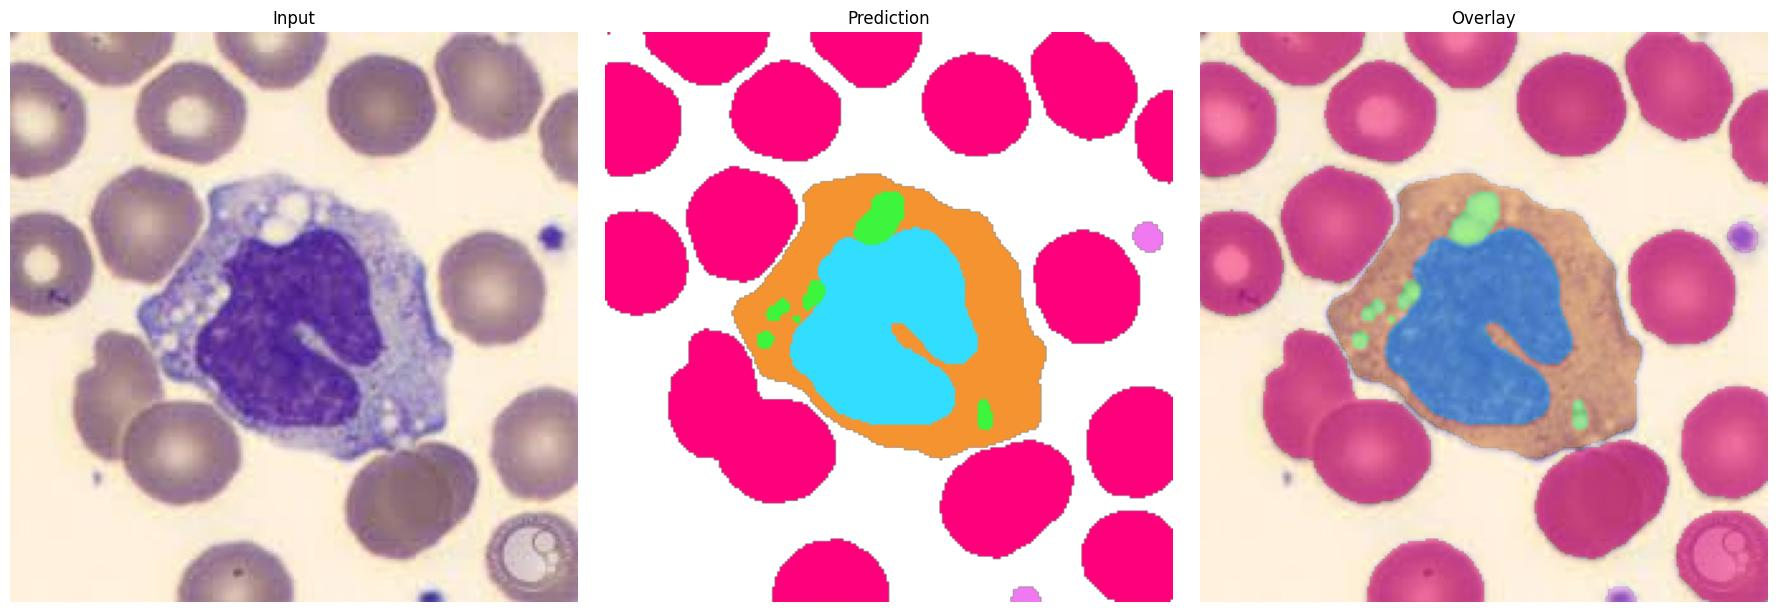

w_ori, h_ori =  500 332


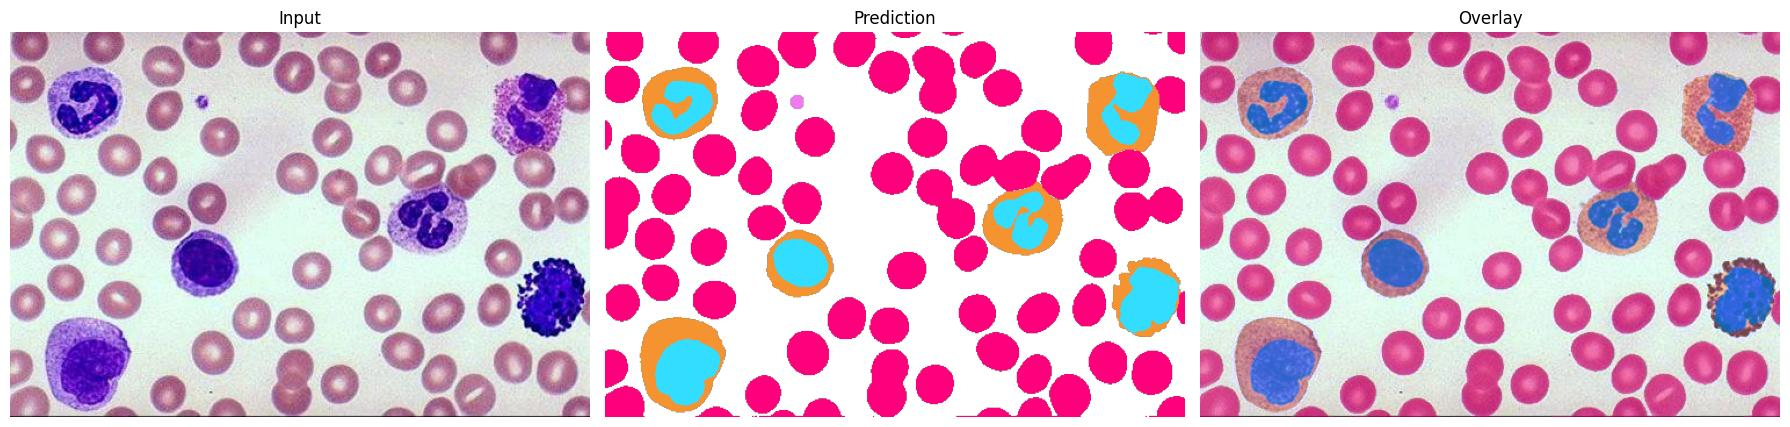

w_ori, h_ori =  480 360


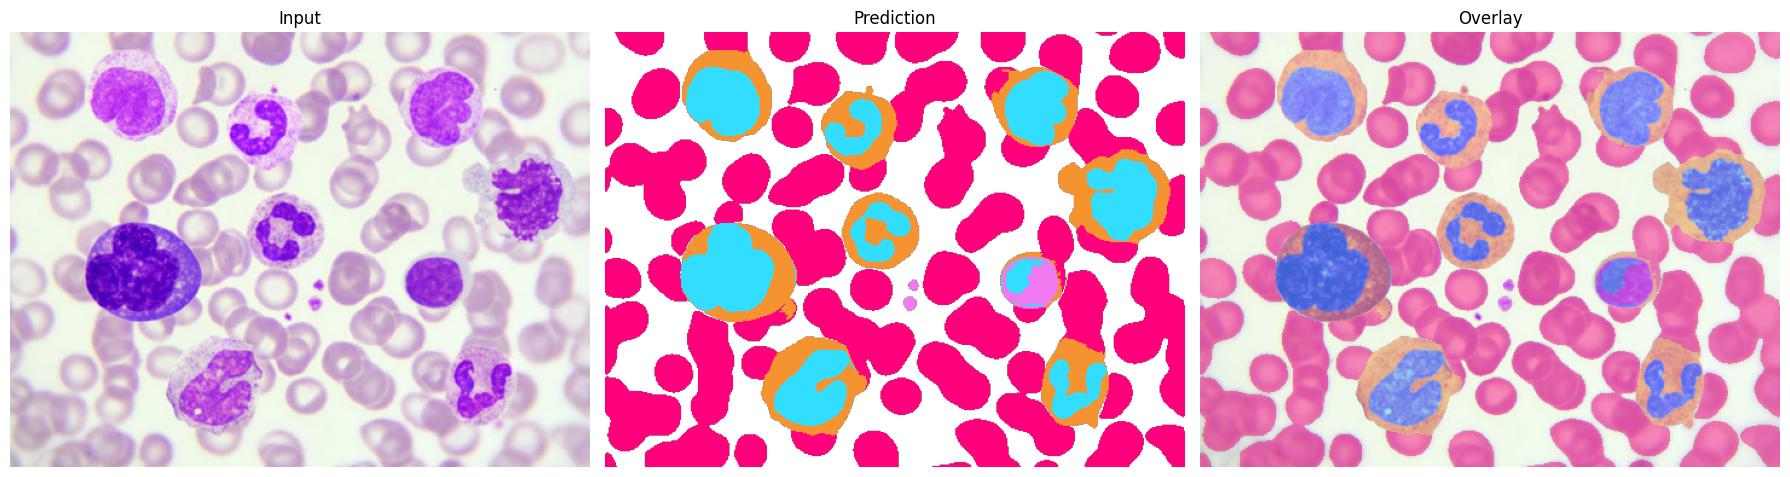

w_ori, h_ori =  1024 820


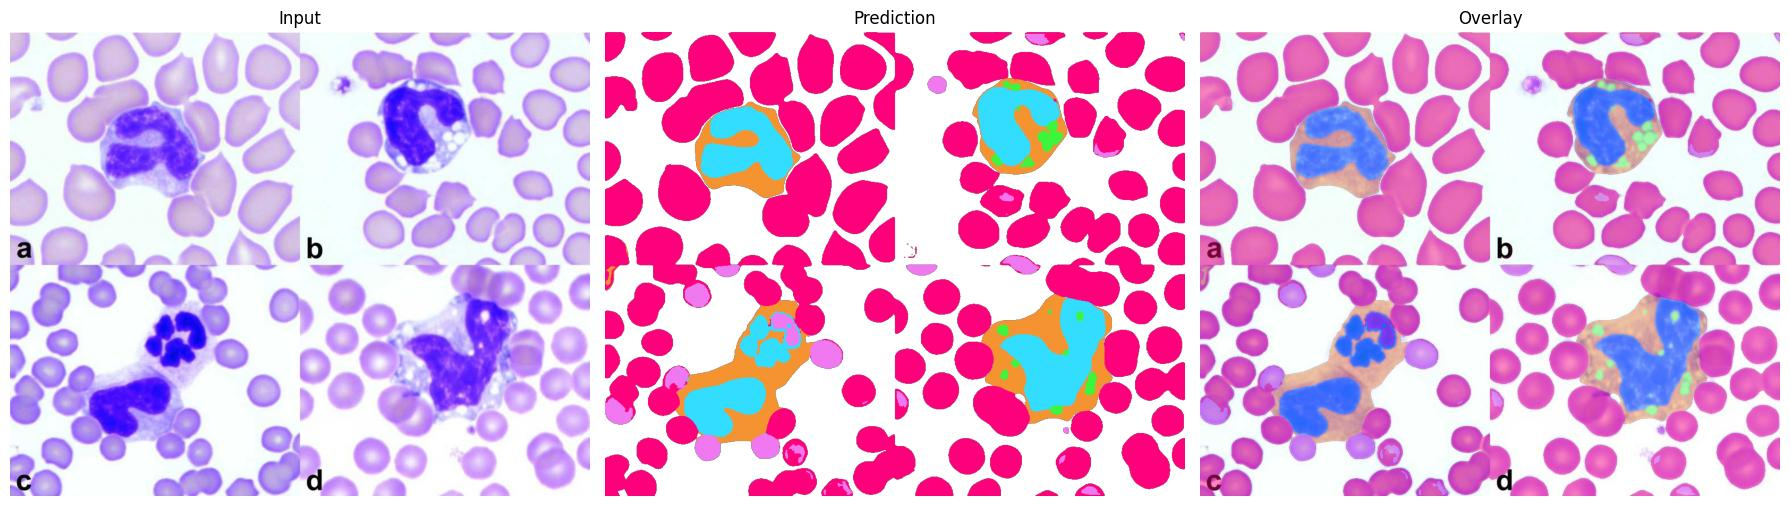

w_ori, h_ori =  1600 1272


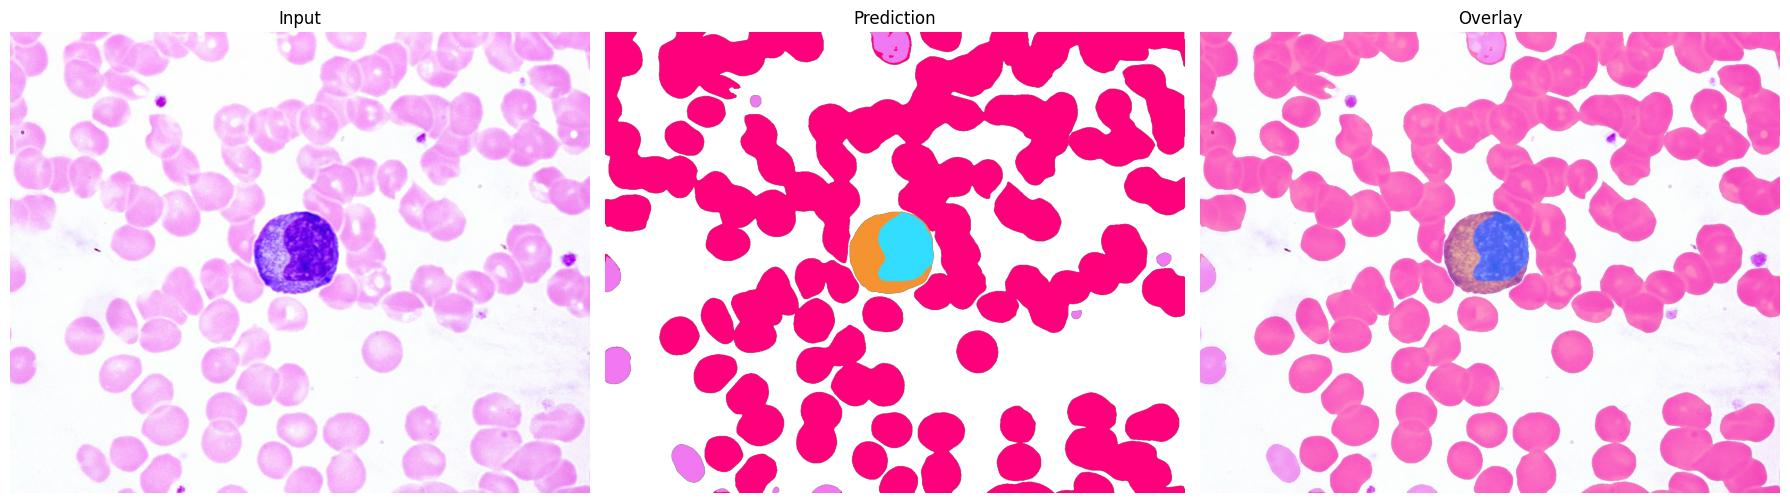

w_ori, h_ori =  292 200


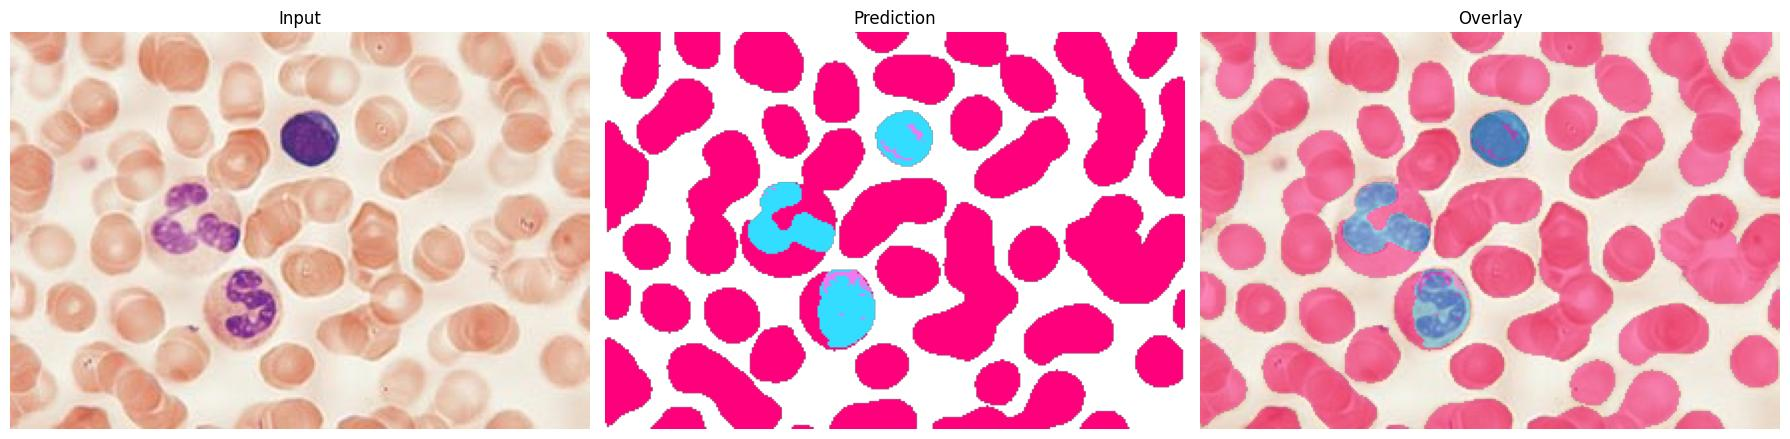

w_ori, h_ori =  300 168


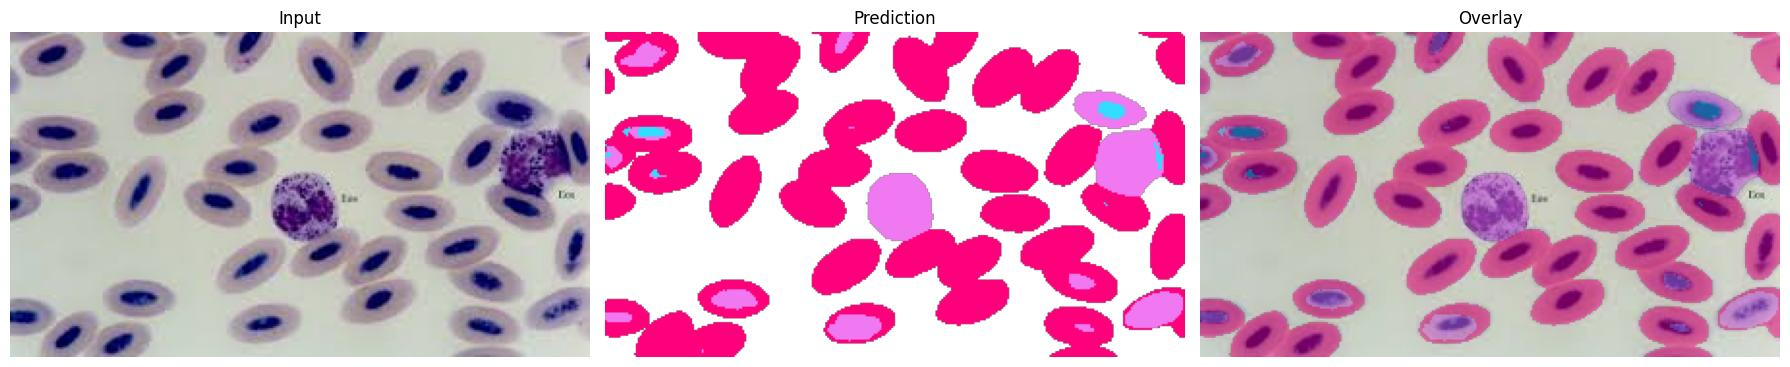

w_ori, h_ori =  1469 1600


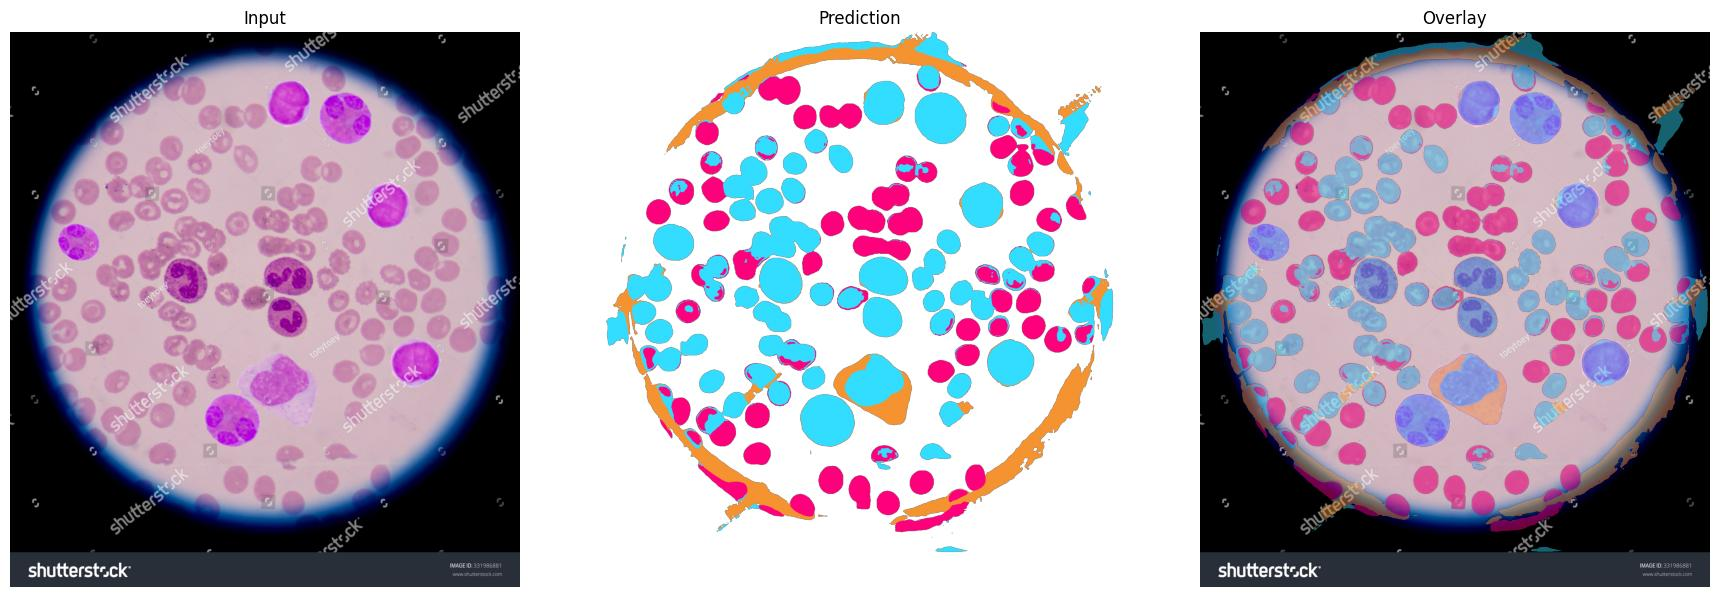

w_ori, h_ori =  234 216


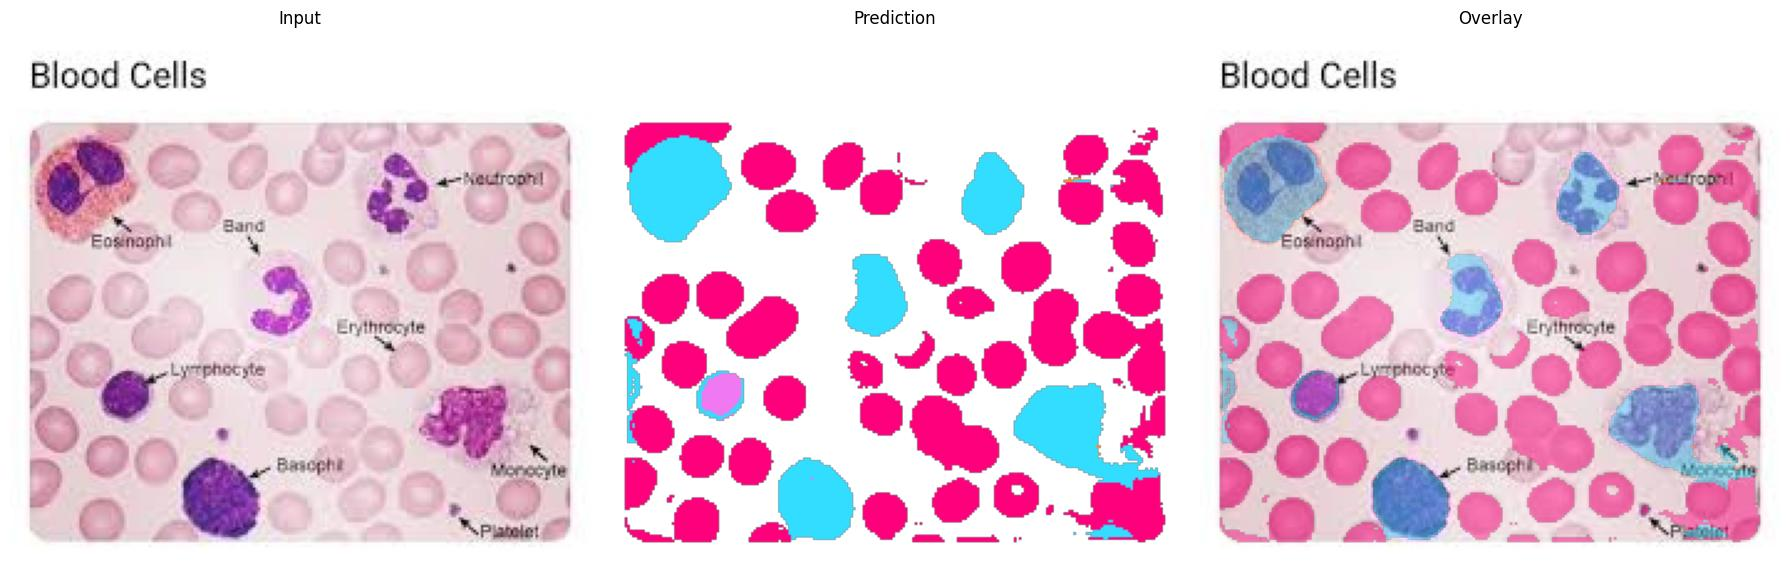

In [6]:
urls = [
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR0s-IdgVVveEjkfL9yIxIOb5VWvPrrFcXliA&s",
    "https://i0.wp.com/www.pathologystudent.com/wp-content/uploads/2009/04/leukocytes.jpg?ssl=1",
    "https://t4.ftcdn.net/jpg/01/22/66/13/360_F_122661320_w2AQFLriJ7WnItMlBhq12wtUSaYdu2Sh.jpg",
    "https://www.saskoer.ca/app/uploads/sites/405/2024/03/Fig_2.10-e1711502835712.jpg",
    "https://cdn.britannica.com/97/271797-050-2D36B9A6/Monocyte-human-white-blood-cell.jpg",
]

# hard cases below
urls_hard = [
    "https://polysciences.com/cdn/shop/files/24985-1_1_1_2d0289ac-cb9e-4fb1-b005-9d3717be9ee1-320083.jpg?v=1737984102",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQglYwWsSQOHDVq7U4bf-K9CsDuHRaPVqJr0Q&s",
    "https://www.shutterstock.com/shutterstock/photos/331986881/display_1500/stock-photo-mix-shape-white-blood-cells-concept-funny-wbc-blood-smear-is-often-used-as-a-follow-up-test-to-331986881.jpg",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ2fcBKOx5D-cyD_DbIEoZXCJWxRYPmsWaTOQ&s"
]
urls += urls_hard

for url in urls:
    image = PIL.Image.open(io.BytesIO(requests.get(url).content)).convert("RGB")
    image_tensor = transform(image)
    input_size = None
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        pred_logits = seg_model(image_tensor.cuda(), input_size=input_size ) 
    pred = pred_logits[0].argmax(dim=0).cpu().numpy()

    w_ori, h_ori = image.size
    print("w_ori, h_ori = ", w_ori, h_ori)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image); axes[0].set_title('Input'); axes[0].axis('off')
    axes[1].imshow(pred, cmap=cmap, vmin=0, vmax=5); axes[1].set_title('Prediction'); axes[1].axis('off')
    axes[2].imshow(image); axes[2].imshow(pred, cmap=cmap, vmin=0, vmax=5, alpha=0.45); axes[2].set_title('Overlay'); axes[2].axis('off')

    plt.tight_layout(); plt.show(); plt.close()

w_ori, h_ori =  292 200


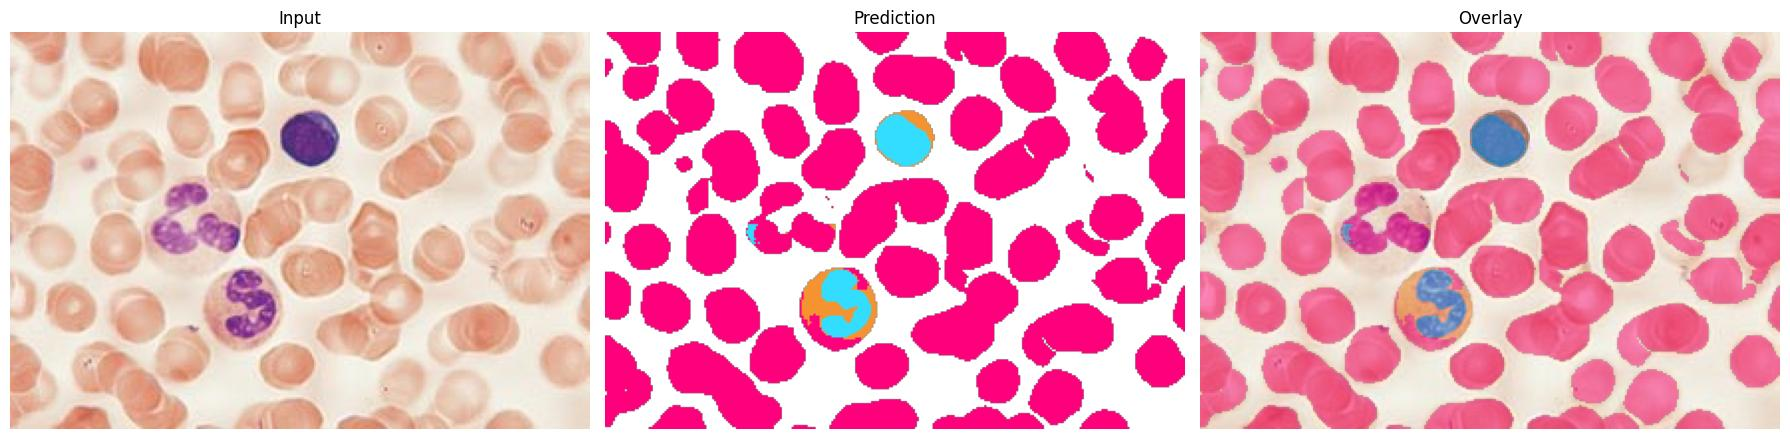

w_ori, h_ori =  300 168


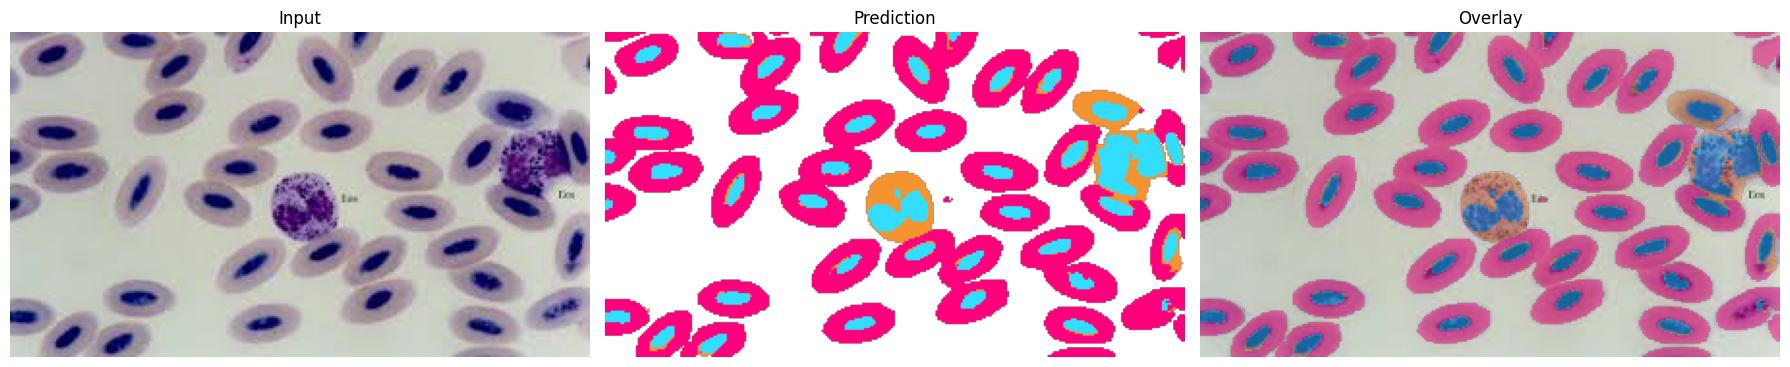

w_ori, h_ori =  1469 1600


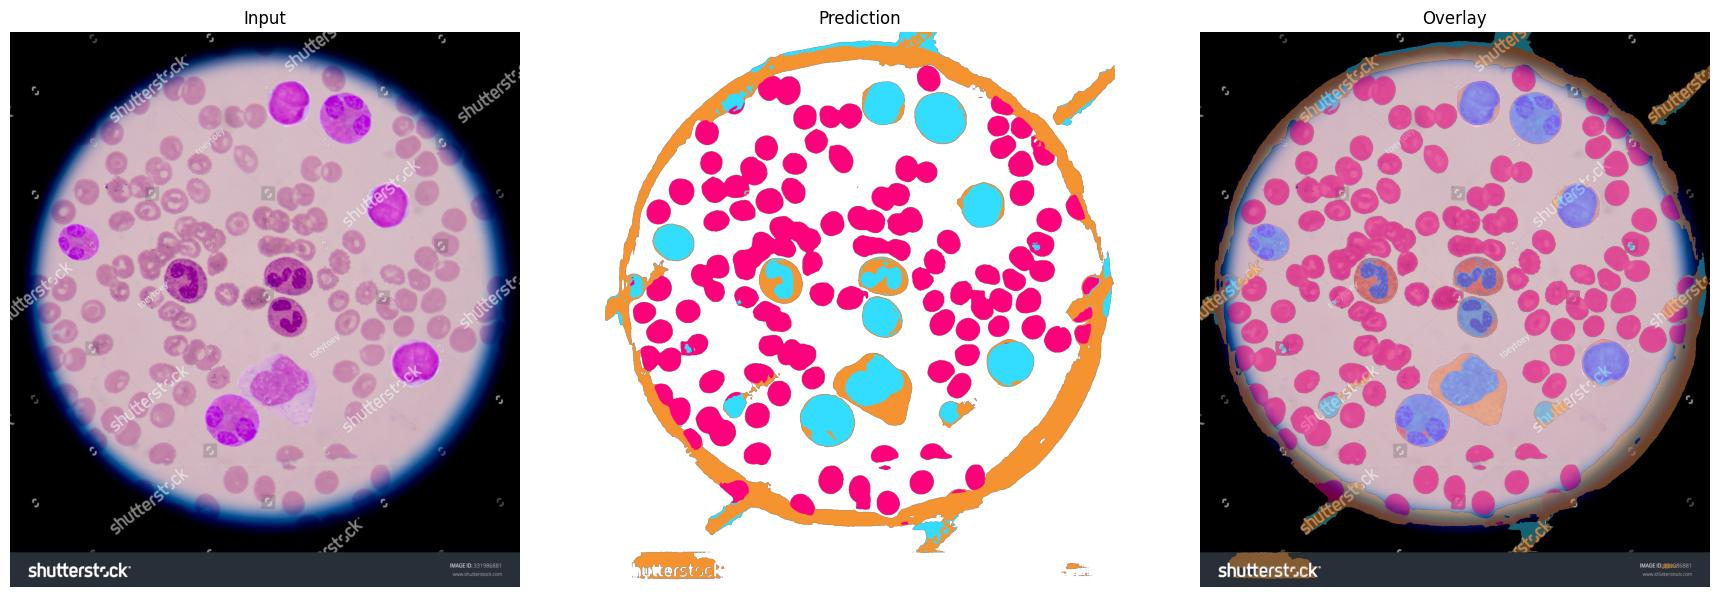

w_ori, h_ori =  234 216


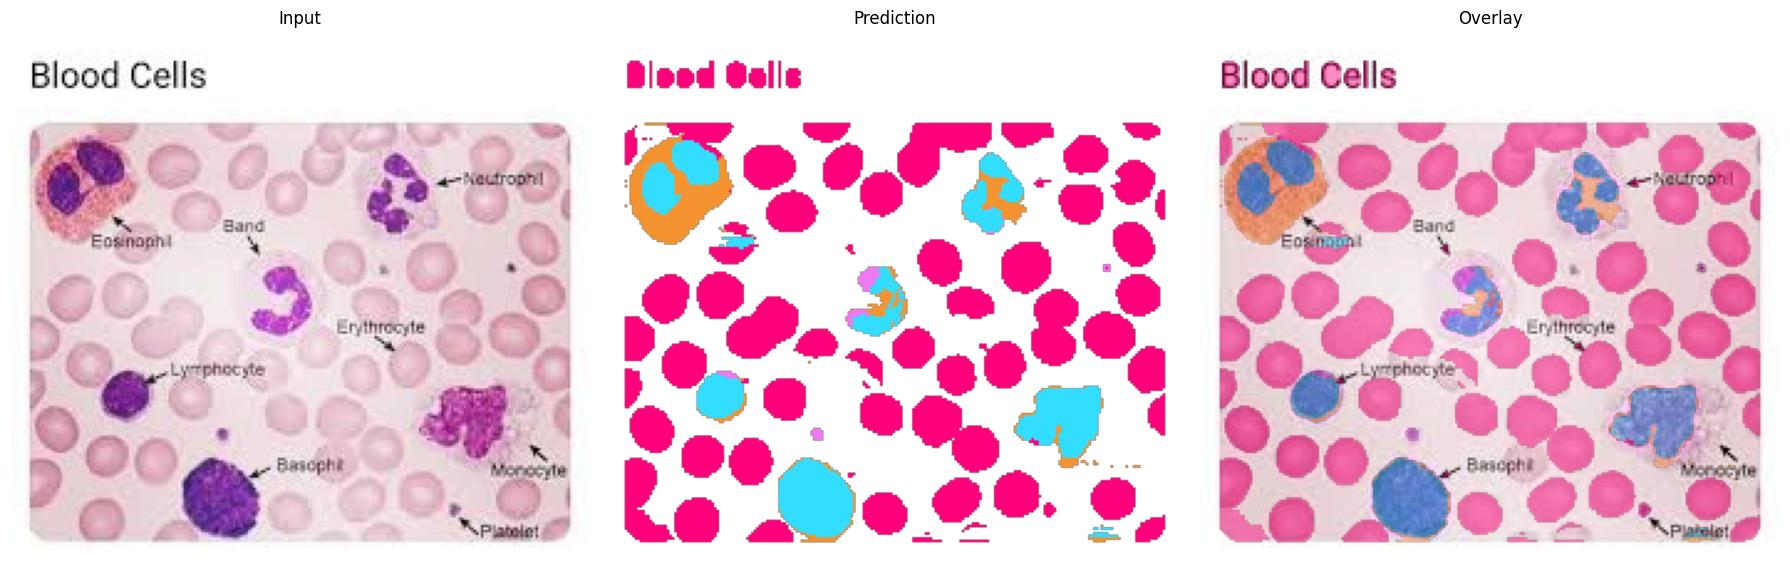

In [ ]:
#input size has some effect so try differnet ones if you want to improve
input_size = (3024,3024)
for url in urls_hard:
    image = PIL.Image.open(io.BytesIO(requests.get(url).content)).convert("RGB")
    image_tensor = transform(image)
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        pred_logits = seg_model(image_tensor.cuda(), input_size=input_size )
    pred = pred_logits[0].argmax(dim=0).cpu().numpy()

    w_ori, h_ori = image.size
    print("w_ori, h_ori = ", w_ori, h_ori)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image); axes[0].set_title('Input'); axes[0].axis('off')
    axes[1].imshow(pred, cmap=cmap, vmin=0, vmax=5); axes[1].set_title('Prediction'); axes[1].axis('off')
    axes[2].imshow(image); axes[2].imshow(pred, cmap=cmap, vmin=0, vmax=5, alpha=0.45); axes[2].set_title('Overlay'); axes[2].axis('off')

    plt.tight_layout(); plt.show(); plt.close()